<a href="https://colab.research.google.com/github/muhammadsalek/python-data-science-course/blob/main/Python_Class_02_NumPy_Pandas_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐍 Python for Data Science — Class 02

## NumPy + Pandas + Data Cleaning + Visualization + EDA

**Duration:** ~4 hours  
**Dataset:** Titanic Dataset  
**Instructor:** Salek Data Lab

### Today
1. NumPy for scientific computing  
2. pandas for data analysis  
3. Data cleaning, wrangling & transformation  
4. Matplotlib, Seaborn & Plotly  
5. Descriptive statistics & exploratory data analysis  
6. Basic inferential statistics preview

> Teaching pattern: **Concept → Code → Output → Interpretation → Practice**

## 0. Class Setup

We first import the libraries used throughout the class.

- `numpy` → numerical arrays and scientific computing
- `pandas` → tabular data analysis
- `matplotlib` → foundational plotting
- `seaborn` → statistical plotting
- `plotly` → interactive plotting
- `scipy` → statistical functions

In [1]:
# Import NumPy and give it the conventional short name np.
import numpy as np

# Import pandas and give it the conventional short name pd.
import pandas as pd

# Import Matplotlib's pyplot interface for plotting.
import matplotlib.pyplot as plt

# Import Seaborn for statistical graphics.
import seaborn as sns

# Import Plotly Express for interactive graphics.
import plotly.express as px

# Import SciPy's statistics module for inferential tests.
from scipy import stats

# Import Path to work with file paths cleanly.
from pathlib import Path

# Make pandas display more columns when we inspect a DataFrame.
pd.set_option("display.max_columns", 50)

# Set a clean Seaborn plotting theme.
sns.set_theme(style="whitegrid")

# Use the first color from the active plotting theme for single-series Seaborn plots.
DEFAULT_COLOR = sns.color_palette()[0]

print("Libraries imported successfully.")

Libraries imported successfully.
Libraries imported successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 1. Load the Titanic Dataset

The notebook searches for the CSV in common locations.  
If it cannot find the file in Google Colab, it opens the upload dialog.

**Expected file name:** `Titanic-Dataset.csv`

In [2]:
from pathlib import Path
import pandas as pd

# Define the dataset path.
DATA_PATH = Path("/content/Titanic-Dataset.csv")

# Check whether the dataset exists.
if not DATA_PATH.exists():
    try:
        from google.colab import files
        uploaded = files.upload()
        DATA_PATH = Path(next(iter(uploaded.keys())))
    except Exception as e:
        raise FileNotFoundError(
            "Titanic-Dataset.csv was not found. Please upload the file and run this cell again."
        ) from e

# Read the CSV file into a pandas DataFrame.
df_raw = pd.read_csv(DATA_PATH)

# Display the first five observations.
df_raw.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Print the number of rows and columns.
print("Shape:", df_raw.shape)

# Print the column names.
print("\nColumns:")
print(df_raw.columns.tolist())

# Print the pandas data type of every column.
print("\nData types:")
print(df_raw.dtypes)

# Count missing values in each column.
print("\nMissing values:")
print(df_raw.isna().sum())

# Count exact duplicate rows.
print("\nExact duplicate rows:", df_raw.duplicated().sum())

Shape: (891, 12)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Exact duplicate rows: 0


# Module 2 — Scientific Python with NumPy

NumPy is the foundation of much of the scientific Python ecosystem.

We will cover:

- arrays and dimensions;
- indexing and slicing;
- element-wise operations;
- Boolean filtering;
- broadcasting;
- vectorization;
- statistics;
- linear algebra;
- random numbers.

## 2.1 Creating NumPy Arrays

In [4]:
# Create a one-dimensional NumPy array.
scores = np.array([65, 72, 80, 91, 88])

# Display the array.
print("Array:", scores)

# Display the Python/NumPy object type.
print("Object type:", type(scores))

# Display the data type stored inside the array.
print("Element dtype:", scores.dtype)

Array: [65 72 80 91 88]
Object type: <class 'numpy.ndarray'>
Element dtype: int64


In [5]:
# Create a two-dimensional array.
matrix = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

# Print the matrix.
print(matrix)

# shape gives the size along each dimension.
print("Shape:", matrix.shape)

# ndim gives the number of dimensions.
print("Dimensions:", matrix.ndim)

# size gives the total number of elements.
print("Total elements:", matrix.size)

[[1 2 3]
 [4 5 6]
 [7 8 9]]
Shape: (3, 3)
Dimensions: 2
Total elements: 9


## 2.2 Indexing and Slicing

In [6]:
# Create a simple array for indexing practice.
x = np.array([10, 20, 30, 40, 50, 60])

# First value: Python indexing starts at 0.
print("First:", x[0])

# Last value: -1 means the final position.
print("Last:", x[-1])

# Slice from index 1 up to, but not including, index 4.
print("x[1:4]:", x[1:4])

# First three values.
print("x[:3]:", x[:3])

# Every second value.
print("x[::2]:", x[::2])

First: 10
Last: 60
x[1:4]: [20 30 40]
x[:3]: [10 20 30]
x[::2]: [10 30 50]


In [ ]:
# Select the value in row 0, column 1.
print("matrix[0, 1] =", matrix[0, 1])

# Select the first row.
print("First row:", matrix[0, :])

# Select the second column.
print("Second column:", matrix[:, 1])

# Select a 2 x 2 block from the upper-left area.
print("2x2 block:\n", matrix[:2, :2])

## 2.3 Array Operations & Vectorization

In [7]:
# Create a numeric array.
a = np.array([1, 2, 3, 4, 5])

# Add 10 to every element.
print("a + 10 =", a + 10)

# Multiply every element by 2.
print("a * 2 =", a * 2)

# Square every element.
print("a squared =", a ** 2)

# Take the square root of every element.
print("sqrt(a) =", np.sqrt(a))

a + 10 = [11 12 13 14 15]
a * 2 = [ 2  4  6  8 10]
a squared = [ 1  4  9 16 25]
sqrt(a) = [1.         1.41421356 1.73205081 2.         2.23606798]


In [8]:
# A normal Python loop can square each value.
loop_result = []

for value in a:
    loop_result.append(value ** 2)

print("Loop result:", loop_result)

# NumPy vectorization performs the same operation on the complete array.
vectorized_result = a ** 2

print("Vectorized result:", vectorized_result)

Loop result: [np.int64(1), np.int64(4), np.int64(9), np.int64(16), np.int64(25)]
Vectorized result: [ 1  4  9 16 25]


### Why vectorization matters

Vectorized code is usually:

- shorter;
- easier to read;
- optimized for numerical computation;
- faster than manually looping through large numeric arrays.

## 2.4 Boolean Filtering

In [9]:
# Create an array of ages.
ages = np.array([12, 17, 18, 25, 42, 67, 81])

# Build a Boolean condition.
adult_mask = ages >= 18

print("Boolean mask:", adult_mask)

# Use the Boolean mask to keep only adults.
print("Adults:", ages[adult_mask])

Boolean mask: [False False  True  True  True  True  True]
Adults: [18 25 42 67 81]


## 2.5 Broadcasting

In [10]:
# Create a 2 x 3 matrix.
m = np.array([
    [10, 20, 30],
    [40, 50, 60]
])

# A scalar can be broadcast to every element.
print("Matrix + 5:\n", m + 5)

# A length-3 vector can be broadcast across rows.
row_adjustment = np.array([1, 2, 3])

print("\nMatrix + row vector:\n", m + row_adjustment)

Matrix + 5:
 [[15 25 35]
 [45 55 65]]

Matrix + row vector:
 [[11 22 33]
 [41 52 63]]


Broadcasting works when NumPy can make the shapes compatible.

Example:

```text
matrix shape:      (2, 3)
vector shape:         (3,)
                         ↓
broadcast across 2 rows
```

## 2.6 Mathematical & Statistical Functions

In [11]:
# Create a sample array.
values = np.array([10, 12, 15, 18, 20, 25, 30])

# Calculate commonly used summaries.
print("Count:", values.size)
print("Mean:", np.mean(values))
print("Median:", np.median(values))
print("Minimum:", np.min(values))
print("Maximum:", np.max(values))
print("Range:", np.max(values) - np.min(values))

# ddof=1 gives the sample variance and sample standard deviation.
print("Sample variance:", np.var(values, ddof=1))
print("Sample SD:", np.std(values, ddof=1))

# Calculate Q1, median, and Q3.
q1, median, q3 = np.percentile(values, [25, 50, 75])

print("Q1:", q1)
print("Median:", median)
print("Q3:", q3)
print("IQR:", q3 - q1)

Count: 7
Mean: 18.571428571428573
Median: 18.0
Minimum: 10
Maximum: 30
Range: 20
Sample variance: 50.61904761904762
Sample SD: 7.114706432386907
Q1: 13.5
Median: 18.0
Q3: 22.5
IQR: 9.0


## 2.7 Linear Algebra Basics

In [12]:
# Define two matrices.
A = np.array([
    [1, 2],
    [3, 4]
])

B = np.array([
    [5, 6],
    [7, 8]
])

# Element-wise multiplication.
print("Element-wise multiplication:\n", A * B)

# Matrix multiplication using @.
print("\nMatrix multiplication A @ B:\n", A @ B)

# Transpose of A.
print("\nTranspose of A:\n", A.T)

# Determinant of A.
print("\nDeterminant of A:", np.linalg.det(A))

# Inverse of A.
print("\nInverse of A:\n", np.linalg.inv(A))

Element-wise multiplication:
 [[ 5 12]
 [21 32]]

Matrix multiplication A @ B:
 [[19 22]
 [43 50]]

Transpose of A:
 [[1 3]
 [2 4]]

Determinant of A: -2.0000000000000004

Inverse of A:
 [[-2.   1. ]
 [ 1.5 -0.5]]


In [13]:
# Solve a simple system of linear equations:
# 2x + y = 5
# x - y = 1

coefficients = np.array([
    [2, 1],
    [1, -1]
])

constants = np.array([5, 1])

solution = np.linalg.solve(coefficients, constants)

print("x =", solution[0])
print("y =", solution[1])

x = 2.0
y = 1.0


## 2.8 Random Number Generation

In [14]:
# Create a modern NumPy random-number generator.
rng = np.random.default_rng(42)

# Generate 10 normally distributed values.
normal_sample = rng.normal(
    loc=100,     # mean
    scale=15,    # standard deviation
    size=10      # number of values
)

print(normal_sample)

[104.5707562   84.40023841 111.25676794 114.10847075  70.73447217
  80.4673074  101.91760605  95.25636111  99.74798264  87.20434109]


In [15]:
# Generate 1,000 random observations for visualization.
simulated_data = rng.normal(loc=100, scale=15, size=1000)

# Calculate the simulated mean and SD.
print("Mean:", simulated_data.mean())
print("SD:", simulated_data.std(ddof=1))

Mean: 99.63502842448108
SD: 14.791155084537092


# Module 3 — pandas for Data Analysis

Now we move from general NumPy arrays to labeled tabular data.

## 3.1 Series and DataFrame

In [16]:
# Create a pandas Series.
age_series = pd.Series([22, 24, 21, 28], name="age")

print(age_series)

0    22
1    24
2    21
3    28
Name: age, dtype: int64


In [17]:
# Create a small DataFrame.
student_df = pd.DataFrame({
    "name": ["Ayesha", "Rahim", "Nadia"],
    "age": [22, 24, 21],
    "score": [88, 75, 91]
})

student_df

,name,age,score
0,Ayesha,22,88
1,Rahim,24,75
2,Nadia,21,91


## 3.2 Importing CSV, Excel, JSON & Stata

In [18]:
from pathlib import Path

# Select a small subset for demonstrating different file formats.
format_demo = df_raw[
    ["PassengerId", "Survived", "Pclass", "Sex", "Age", "Fare"]
].head(50).copy()

# Set the output directory.
WORK_DIR = Path("/content")

# Define output file paths.
csv_path = WORK_DIR / "format_demo.csv"
excel_path = WORK_DIR / "format_demo.xlsx"
json_path = WORK_DIR / "format_demo.json"
stata_path = WORK_DIR / "format_demo.dta"

# Export the same data to different file formats.
format_demo.to_csv(csv_path, index=False)
format_demo.to_excel(excel_path, index=False)
format_demo.to_json(json_path, orient="records")
format_demo.to_stata(stata_path, write_index=False)

# Confirm that the files were created.
print("Files created successfully:")
print(f"CSV:   {csv_path}")
print(f"Excel: {excel_path}")
print(f"JSON:  {json_path}")
print(f"Stata: {stata_path}")

Files created successfully:
CSV:   /content/format_demo.csv
Excel: /content/format_demo.xlsx
JSON:  /content/format_demo.json
Stata: /content/format_demo.dta


In [19]:
# Import the CSV file.
demo_csv = pd.read_csv(csv_path)

# Import the Excel file.
demo_excel = pd.read_excel(excel_path)

# Import the JSON file.
demo_json = pd.read_json(json_path)

# Import the Stata file.
demo_stata = pd.read_stata(stata_path)

# Compare shapes.
print("CSV:", demo_csv.shape)
print("Excel:", demo_excel.shape)
print("JSON:", demo_json.shape)
print("Stata:", demo_stata.shape)

CSV: (50, 6)
Excel: (50, 6)
JSON: (50, 6)
Stata: (50, 6)


## 3.3 Create a Working Copy

In [20]:
# Keep the original data unchanged.
titanic_raw = df_raw.copy()

# Create a working copy for cleaning and analysis.
titanic = df_raw.copy()

print("Raw shape:", titanic_raw.shape)
print("Working shape:", titanic.shape)

Raw shape: (891, 12)
Working shape: (891, 12)


## 3.4 Standardize Column Names

In [ ]:
# Convert column names to lowercase.
titanic.columns = titanic.columns.str.lower()

# Replace spaces with underscores if any exist.
titanic.columns = titanic.columns.str.replace(" ", "_", regex=False)

# Display the cleaned column names.
print(titanic.columns.tolist())

## 3.5 Inspect the Dataset

In [21]:
# View the first five rows.
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# View the last five rows.
titanic.tail()

In [ ]:
# View five random rows.
titanic.sample(5, random_state=42)

In [22]:
# Display the dimensions.
print("Rows:", titanic.shape[0])
print("Columns:", titanic.shape[1])

# Display column data types.
print("\nData types:")
print(titanic.dtypes)

Rows: 891
Columns: 12

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [ ]:
# info() gives a compact audit of:
# - row count
# - non-missing counts
# - column data types
# - approximate memory use
titanic.info()

In [ ]:
# describe() summarizes numeric columns by default.
titanic.describe().T

In [ ]:
# include="all" also gives useful information for categorical/text columns.
titanic.describe(include="all").T

## 3.6 Selecting Columns

In [ ]:
# Select one column as a Series.
age = titanic["age"]

# Display the first five ages.
age.head()

In [ ]:
# Select multiple columns as a DataFrame.
titanic[["age", "sex", "pclass", "survived"]].head()

## 3.7 `loc` and `iloc`

In [ ]:
# loc selects using labels.
titanic.loc[0:4, ["age", "sex", "survived"]]

In [ ]:
# iloc selects using integer positions.
titanic.iloc[0:5, 0:5]

## 3.8 Filtering Rows

In [ ]:
# Keep passengers aged 18 years or older.
adults = titanic[titanic["age"] >= 18]

print("Adult rows:", adults.shape[0])
adults.head()

In [ ]:
# Combine multiple conditions using &.
first_class_women = titanic[
    (titanic["sex"] == "female") &
    (titanic["pclass"] == 1)
]

first_class_women.head()

In [ ]:
# The query() method offers an alternative readable syntax.
titanic.query("age >= 18 and pclass == 1").head()

## 3.9 Sorting and Ranking

In [ ]:
# Sort passengers from highest to lowest fare.
highest_fares = titanic.sort_values("fare", ascending=False)

highest_fares[["name", "pclass", "fare"]].head(10)

In [ ]:
# Rank fares from highest to lowest.
titanic["fare_rank"] = titanic["fare"].rank(
    method="average",
    ascending=False
)

titanic[["name", "fare", "fare_rank"]].sort_values("fare_rank").head()

# Module 3B — Data Cleaning, Wrangling & Transformation

## 3.10 Audit Missing Values

In [23]:
# Count missing values.
missing_count = titanic.isna().sum()

# Calculate missing percentages.
missing_pct = titanic.isna().mean().mul(100)

# Combine both into one audit table.
missing_table = pd.DataFrame({
    "missing_n": missing_count,
    "missing_percent": missing_pct.round(2)
})

missing_table.sort_values("missing_percent", ascending=False)

,missing_n,missing_percent
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


## 3.11 Clean Text Labels

In [25]:
# Standardize column names to lowercase first to avoid KeyError
titanic.columns = titanic.columns.str.lower()

# Strip accidental spaces and standardize case in sex.
titanic["sex"] = (
    titanic["sex"]
    .astype("string")
    .str.strip()
    .str.lower()
)

# Standardize embarked labels as uppercase.
titanic["embarked"] = (
    titanic["embarked"]
    .astype("string")
    .str.strip()
    .str.upper()
)

print("Sex labels:", titanic["sex"].dropna().unique())
print("Embarked labels:", titanic["embarked"].dropna().unique())

Sex labels: <StringArray>
['male', 'female']
Length: 2, dtype: string
Embarked labels: <StringArray>
['S', 'C', 'Q']
Length: 3, dtype: string


## 3.12 Check Impossible Values

In [26]:
# A human age below 0 would be impossible.
impossible_age = titanic[titanic["age"] < 0]

# A negative ticket fare would be impossible here.
impossible_fare = titanic[titanic["fare"] < 0]

print("Impossible age rows:", len(impossible_age))
print("Impossible fare rows:", len(impossible_fare))

Impossible age rows: 0
Impossible fare rows: 0


In [27]:
# Check the observed minimum and maximum values.
print("Age range:", titanic["age"].min(), "to", titanic["age"].max())
print("Fare range:", titanic["fare"].min(), "to", titanic["fare"].max())

Age range: 0.42 to 80.0
Fare range: 0.0 to 512.3292


## 3.13 Duplicate Detection

In [28]:
# Count exact duplicate rows.
duplicate_n = titanic.duplicated().sum()

print("Exact duplicate rows:", duplicate_n)

# If duplicates exist, this displays them.
titanic[titanic.duplicated(keep=False)].head()

Exact duplicate rows: 0


,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked


In [29]:
# Remove exact duplicates from the working copy.
# If there are no duplicates, the shape will remain unchanged.
titanic = titanic.drop_duplicates().copy()

print("Shape after duplicate check:", titanic.shape)

Shape after duplicate check: (891, 12)


## 3.14 Missing-Value Handling

For teaching purposes we will use simple, transparent strategies:

- `Age` → median within sex and passenger class;
- `Embarked` → mode;
- `Cabin` → create a missingness indicator, then label missing text as `Unknown`.

These choices are for learning.  
For real research, missing-data methods should be justified scientifically and statistically.

In [30]:
# Before filling cabin, record whether a cabin was originally available.
titanic["cabin_known"] = np.where(
    titanic["cabin"].notna(),
    "Known",
    "Unknown"
)

# Display counts.
titanic["cabin_known"].value_counts()

,count
cabin_known,
Unknown,687
Known,204


In [31]:
# Fill missing Age with the median Age within sex and passenger class.
titanic["age"] = titanic["age"].fillna(
    titanic.groupby(["sex", "pclass"])["age"].transform("median")
)

# Fill missing Embarked with the most common non-missing category.
embarked_mode = titanic["embarked"].mode(dropna=True)[0]
titanic["embarked"] = titanic["embarked"].fillna(embarked_mode)

# For descriptive work, replace missing cabin labels with "Unknown".
titanic["cabin"] = titanic["cabin"].fillna("Unknown")

# Check remaining missing values.
titanic.isna().sum()

,0
passengerid,0
survived,0
pclass,0
name,0
sex,0
age,0
sibsp,0
parch,0
ticket,0
fare,0


## 3.15 Convert Appropriate Variables to Categories

In [32]:
# Passenger class is coded numerically but conceptually represents categories.
titanic["pclass"] = titanic["pclass"].astype("category")

# Convert selected text variables to categorical dtype.
for col in ["sex", "embarked", "cabin_known"]:
    titanic[col] = titanic[col].astype("category")

# Display updated data types.
titanic.dtypes

,0
passengerid,int64
survived,int64
pclass,category
name,object
sex,category
age,float64
sibsp,int64
parch,int64
ticket,object
fare,float64


## 3.16 Create New Variables

In [33]:
# Family size = passenger + siblings/spouses + parents/children.
titanic["family_size"] = titanic["sibsp"] + titanic["parch"] + 1

# Create an indicator for traveling alone.
titanic["is_alone"] = np.where(
    titanic["family_size"] == 1,
    "Yes",
    "No"
)

# Avoid division by zero by dividing Fare by family size, which is always at least 1.
titanic["fare_per_person"] = titanic["fare"] / titanic["family_size"]

# Map 0/1 survival into readable labels.
titanic["survival_label"] = titanic["survived"].map({
    0: "Did not survive",
    1: "Survived"
})

titanic[[
    "sibsp", "parch", "family_size",
    "is_alone", "fare", "fare_per_person",
    "survived", "survival_label"
]].head()

,sibsp,parch,family_size,is_alone,fare,fare_per_person,survived,survival_label
0,1,0,2,No,7.2500,3.62500,0,Did not survive
1,1,0,2,No,71.2833,35.64165,1,Survived
2,0,0,1,Yes,7.9250,7.92500,1,Survived
3,1,0,2,No,53.1000,26.55000,1,Survived
4,0,0,1,Yes,8.0500,8.05000,0,Did not survive


## 3.17 Extract a Title from Passenger Name

In [34]:
# Titanic names commonly contain titles such as Mr., Mrs., Miss., Master.
# Extract the text appearing after the comma and before the period.
titanic["title"] = titanic["name"].str.extract(r",\s*([^.]*)\.", expand=False)

# Remove leading/trailing spaces.
titanic["title"] = titanic["title"].str.strip()

# Inspect the most common titles.
titanic["title"].value_counts().head(15)

,count
title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


## 3.18 `map()` Example

In [35]:
# Map passenger classes to readable labels.
pclass_labels = {
    1: "First",
    2: "Second",
    3: "Third"
}

# Convert category values to int before mapping.
titanic["class_label"] = titanic["pclass"].astype(int).map(pclass_labels)

titanic[["pclass", "class_label"]].head()

,pclass,class_label
0,3,Third
1,1,First
2,3,Third
3,1,First
4,3,Third


## 3.19 `apply()` Example

In [36]:
# Define a simple age-category function.
def classify_age(age):
    if age < 18:
        return "Child"
    elif age < 60:
        return "Adult"
    else:
        return "Older adult"

# Apply the function to every value in the age column.
titanic["age_group"] = titanic["age"].apply(classify_age)

titanic["age_group"].value_counts()

,count
age_group,
Adult,752
Child,113
Older adult,26


## 3.20 Outlier Detection with the IQR Rule

In [37]:
# Define a reusable function that returns lower and upper IQR fences.
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return lower, upper

# Calculate fare fences.
fare_lower, fare_upper = iqr_bounds(titanic["fare"])

print("Fare lower fence:", fare_lower)
print("Fare upper fence:", fare_upper)

Fare lower fence: -26.724
Fare upper fence: 65.6344


In [38]:
# Flag fare observations outside the IQR fences.
titanic["fare_outlier"] = (
    (titanic["fare"] < fare_lower) |
    (titanic["fare"] > fare_upper)
)

# Count flagged observations.
print(titanic["fare_outlier"].value_counts())

# Inspect some flagged observations.
titanic.loc[
    titanic["fare_outlier"],
    ["name", "pclass", "fare"]
].sort_values("fare", ascending=False).head(10)

fare_outlier
False    775
True     116
Name: count, dtype: int64


,name,pclass,fare
258,"Ward, Miss. Anna",1,512.3292
737,"Lesurer, Mr. Gustave J",1,512.3292
679,"Cardeza, Mr. Thomas Drake Martinez",1,512.3292
27,"Fortune, Mr. Charles Alexander",1,263.0000
341,"Fortune, Miss. Alice Elizabeth",1,263.0000
438,"Fortune, Mr. Mark",1,263.0000
88,"Fortune, Miss. Mabel Helen",1,263.0000
311,"Ryerson, Miss. Emily Borie",1,262.3750
742,"Ryerson, Miss. Susan Parker ""Suzette""",1,262.3750
299,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",1,247.5208


> **Important:** An outlier is not automatically an error.  
> On the Titanic, expensive fares can be genuine observations.  
> Flag → inspect → understand → then decide.

## 3.21 `groupby()`

In [39]:
# Calculate survival proportion by sex.
survival_by_sex = (
    titanic
    .groupby("sex", observed=False)["survived"]
    .mean()
    .mul(100)
    .round(1)
)

survival_by_sex

,survived
sex,
female,74.2
male,18.9


## 3.22 Aggregation

In [40]:
# Produce several summaries by passenger class.
class_summary = (
    titanic
    .groupby("pclass", observed=False)
    .agg(
        passengers=("passengerid", "count"),
        survival_rate=("survived", "mean"),
        mean_age=("age", "mean"),
        median_fare=("fare", "median")
    )
)

# Convert survival proportion to percentage.
class_summary["survival_rate"] *= 100

class_summary.round(2)

,passengers,survival_rate,mean_age,median_fare
pclass,,,,
1,216,62.96,38.27,60.29
2,184,47.28,29.86,14.25
3,491,24.24,24.80,8.05


## 3.23 Merge

In [41]:
# Create one table with passenger IDs and demographics.
demographics = titanic[
    ["passengerid", "sex", "age"]
].head(10).copy()

# Create another table with passenger IDs and outcomes.
outcomes = titanic[
    ["passengerid", "survived", "fare"]
].head(10).copy()

# Merge using passengerid as the key.
merged_demo = demographics.merge(
    outcomes,
    on="passengerid",
    how="left"
)

merged_demo

,passengerid,sex,age,survived,fare
0,1,male,22.0,0,7.2500
1,2,female,38.0,1,71.2833
2,3,female,26.0,1,7.9250
3,4,female,35.0,1,53.1000
4,5,male,35.0,0,8.0500
5,6,male,25.0,0,8.4583
6,7,male,54.0,0,51.8625
7,8,male,2.0,0,21.0750
8,9,female,27.0,1,11.1333
9,10,female,14.0,1,30.0708


## 3.24 Join

In [42]:
# Set passengerid as the index in both tables.
left_indexed = demographics.set_index("passengerid")
right_indexed = outcomes.set_index("passengerid")

# Join the second table to the first using the index.
joined_demo = left_indexed.join(right_indexed)

joined_demo.head()

,sex,age,survived,fare
passengerid,,,,
1,male,22.0,0,7.2500
2,female,38.0,1,71.2833
3,female,26.0,1,7.9250
4,female,35.0,1,53.1000
5,male,35.0,0,8.0500


## 3.25 Concatenate

In [43]:
# Split a small sample into two parts.
part_a = titanic.head(5)
part_b = titanic.iloc[5:10]

# Stack the rows back together.
combined_rows = pd.concat(
    [part_a, part_b],
    axis=0,
    ignore_index=True
)

combined_rows

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,cabin_known,family_size,is_alone,fare_per_person,survival_label,title,class_label,age_group,fare_outlier
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,Unknown,2,No,3.62500,Did not survive,Mr,Third,Adult,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Known,2,No,35.64165,Survived,Mrs,First,Adult,True
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,Unknown,1,Yes,7.92500,Survived,Miss,Third,Adult,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Known,2,No,26.55000,Survived,Mrs,First,Adult,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,Unknown,1,Yes,8.05000,Did not survive,Mr,Third,Adult,False
5,6,0,3,"Moran, Mr. James",male,25.0,0,0,330877,8.4583,Unknown,Q,Unknown,1,Yes,8.45830,Did not survive,Mr,Third,Adult,False
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,Known,1,Yes,51.86250,Did not survive,Mr,First,Adult,False
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,Unknown,S,Unknown,5,No,4.21500,Did not survive,Master,Third,Child,False
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,Unknown,S,Unknown,3,No,3.71110,Survived,Mrs,Third,Adult,False
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,Unknown,C,Unknown,2,No,15.03540,Survived,Mrs,Second,Child,False


## 3.26 Pivot Table

In [44]:
# Build a table of mean survival proportion by sex and passenger class.
survival_pivot = pd.pivot_table(
    titanic,
    values="survived",
    index="sex",
    columns="pclass",
    aggfunc="mean",
    observed=False
)

# Convert proportions to percentages.
survival_pivot * 100

pclass,1,2,3
sex,,,
female,96.808511,92.105263,50.000000
male,36.885246,15.740741,13.544669


## 3.27 Reshape Wide → Long with `melt()`

In [45]:
# Create a small wide-format summary.
wide_example = titanic[
    ["passengerid", "age", "fare"]
].head(5)

print("Wide format:")
display(wide_example)

# Reshape age and fare into one measurement column.
long_example = wide_example.melt(
    id_vars="passengerid",
    value_vars=["age", "fare"],
    var_name="measure",
    value_name="value"
)

print("\nLong format:")
display(long_example)

Wide format:


,passengerid,age,fare
0,1,22.0,7.2500
1,2,38.0,71.2833
2,3,26.0,7.9250
3,4,35.0,53.1000
4,5,35.0,8.0500



Long format:


,passengerid,measure,value
0,1,age,22.0000
1,2,age,38.0000
2,3,age,26.0000
3,4,age,35.0000
4,5,age,35.0000
5,1,fare,7.2500
6,2,fare,71.2833
7,3,fare,7.9250
8,4,fare,53.1000
9,5,fare,8.0500


## 3.28 Final Cleaning Audit

In [46]:
# Create a compact audit table after cleaning.
final_audit = pd.DataFrame({
    "dtype": titanic.dtypes.astype(str),
    "missing_n": titanic.isna().sum(),
    "missing_percent": (titanic.isna().mean() * 100).round(2),
    "unique_n": titanic.nunique(dropna=True)
})

final_audit

,dtype,missing_n,missing_percent,unique_n
passengerid,int64,0,0.0,891
survived,int64,0,0.0,2
pclass,category,0,0.0,3
name,object,0,0.0,891
sex,category,0,0.0,2
age,float64,0,0.0,89
sibsp,int64,0,0.0,7
parch,int64,0,0.0,7
ticket,object,0,0.0,681
fare,float64,0,0.0,248


# Module 4 — Descriptive Statistics

## 4.1 Numerical Descriptive Summary

In [47]:
# Choose important numeric variables.
numeric_vars = [
    "age",
    "sibsp",
    "parch",
    "fare",
    "family_size",
    "fare_per_person"
]

# Standard pandas descriptive summary.
titanic[numeric_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
age,891.0,29.112424,13.304424,0.42,21.5000,26.0000,36.000000,80.0000
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.000000,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.000000,6.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.000000,512.3292
family_size,891.0,1.904602,1.613459,1.00,1.0000,1.0000,2.000000,11.0000
fare_per_person,891.0,19.916375,35.841257,0.00,7.2500,8.3000,23.666667,512.3292


## 4.2 Mean, Median, Variance, SD, IQR & Skewness

In [48]:
# Select age as an example numeric variable.
age_values = titanic["age"]

# Compute key descriptive measures.
age_mean = age_values.mean()
age_median = age_values.median()
age_variance = age_values.var(ddof=1)
age_sd = age_values.std(ddof=1)
age_q1 = age_values.quantile(0.25)
age_q3 = age_values.quantile(0.75)
age_iqr = age_q3 - age_q1
age_skewness = age_values.skew()

print("Mean:", round(age_mean, 2))
print("Median:", round(age_median, 2))
print("Variance:", round(age_variance, 2))
print("SD:", round(age_sd, 2))
print("Q1:", round(age_q1, 2))
print("Q3:", round(age_q3, 2))
print("IQR:", round(age_iqr, 2))
print("Skewness:", round(age_skewness, 2))

Mean: 29.11
Median: 26.0
Variance: 177.01
SD: 13.3
Q1: 21.5
Q3: 36.0
IQR: 14.5
Skewness: 0.53


## 4.3 Frequency and Percentage Tables

In [49]:
# Frequency counts.
sex_frequency = titanic["sex"].value_counts()

# Percentages.
sex_percent = titanic["sex"].value_counts(normalize=True).mul(100)

# Combine both.
sex_table = pd.DataFrame({
    "frequency": sex_frequency,
    "percent": sex_percent.round(2)
})

sex_table

,frequency,percent
sex,,
male,577,64.76
female,314,35.24


In [50]:
# Survival frequency table.
survival_table = (
    titanic["survival_label"]
    .value_counts()
    .rename_axis("survival")
    .reset_index(name="frequency")
)

# Add percentage.
survival_table["percent"] = (
    survival_table["frequency"] /
    survival_table["frequency"].sum() *
    100
).round(2)

survival_table

,survival,frequency,percent
0,Did not survive,549,61.62
1,Survived,342,38.38


# Module 5 — Data Visualization

## 5.1 Matplotlib Histogram

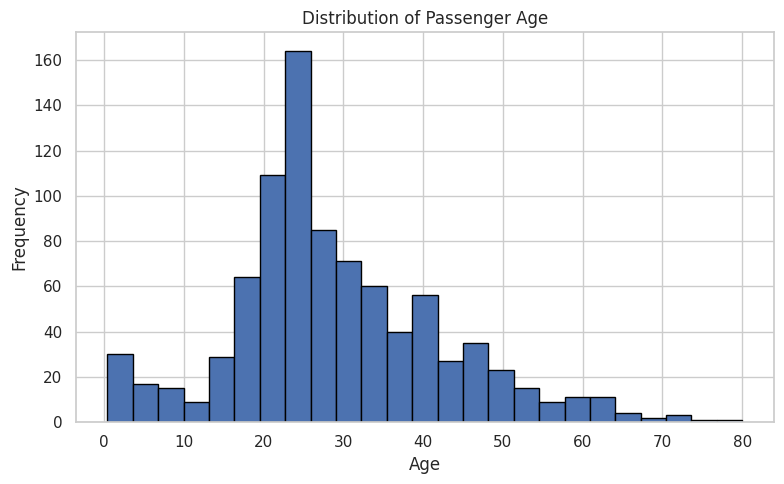

In [51]:
# Create a new figure.
plt.figure(figsize=(8, 5))

# Plot the age distribution.
plt.hist(
    titanic["age"],
    bins=25,
    edgecolor="black"
)

# Add labels.
plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

# Improve spacing.
plt.tight_layout()

# Display the figure.
plt.show()

## 5.2 Seaborn Histogram + KDE

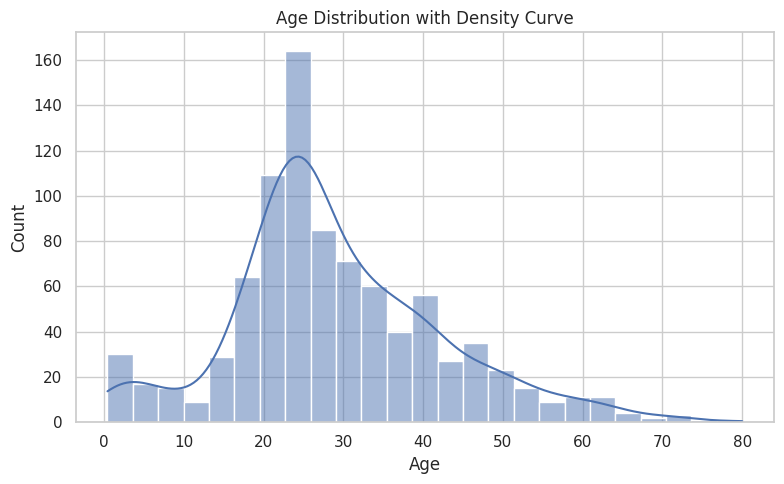

In [52]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=titanic,
    x="age",
    bins=25,
    kde=True,
    color=DEFAULT_COLOR
)

plt.title("Age Distribution with Density Curve")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 5.3 Count Plot

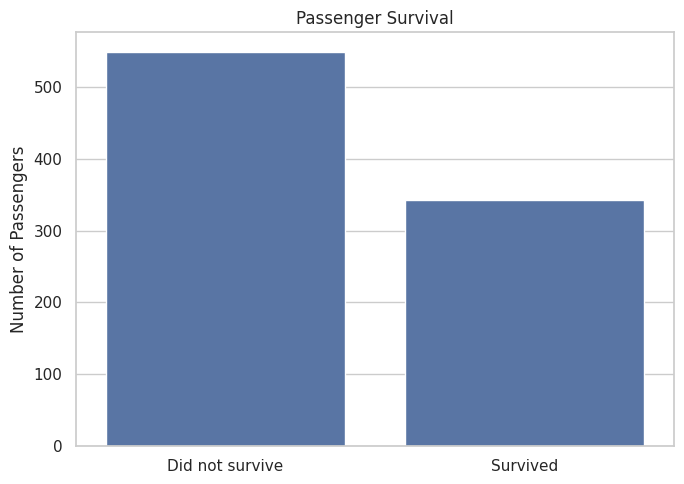

In [53]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=titanic,
    x="survival_label",
    color=DEFAULT_COLOR
)

plt.title("Passenger Survival")
plt.xlabel("")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()

## 5.4 Bar Plot — Survival Rate by Sex

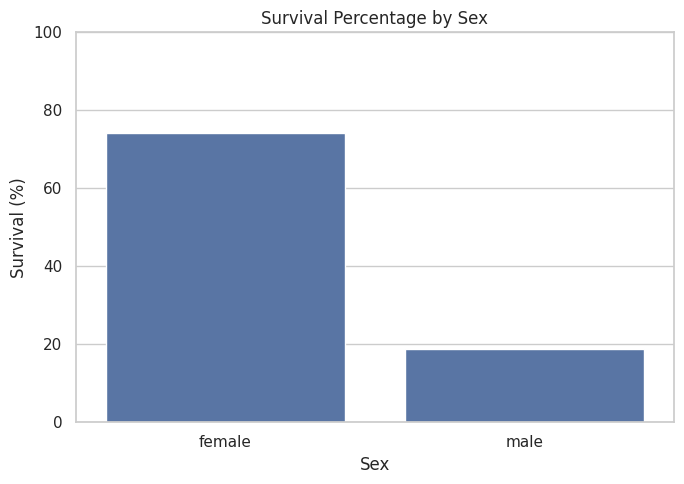

In [54]:
# Calculate survival percentage by sex.
plot_data = (
    titanic
    .groupby("sex", observed=False)["survived"]
    .mean()
    .mul(100)
    .reset_index(name="survival_percent")
)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=plot_data,
    x="sex",
    y="survival_percent",
    color=DEFAULT_COLOR
)

plt.title("Survival Percentage by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## 5.5 Box Plot

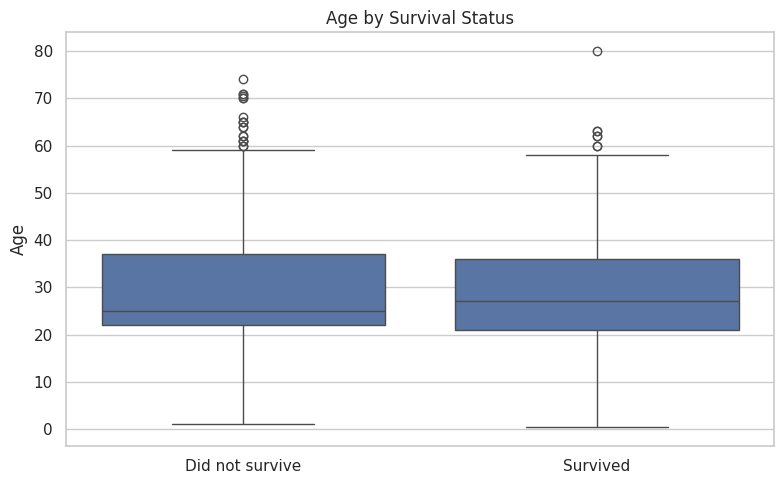

In [55]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=titanic,
    x="survival_label",
    y="age"
)

plt.title("Age by Survival Status")
plt.xlabel("")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

## 5.6 Scatter Plot

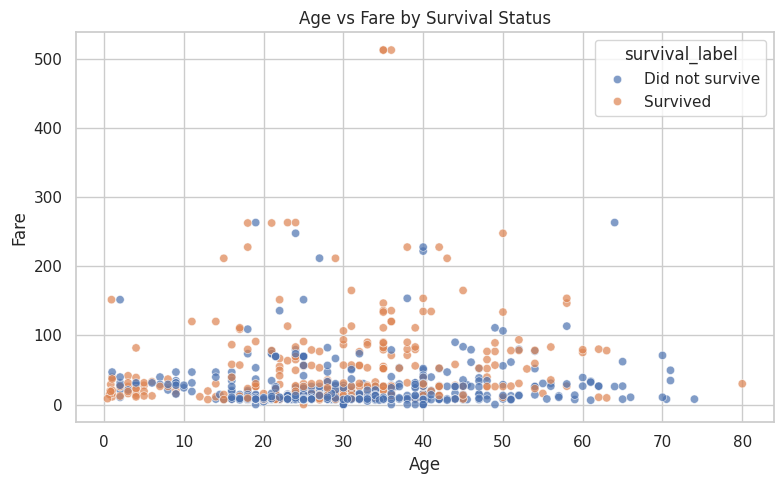

In [56]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=titanic,
    x="age",
    y="fare",
    hue="survival_label",
    alpha=0.7
)

plt.title("Age vs Fare by Survival Status")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()

## 5.7 Line Plot

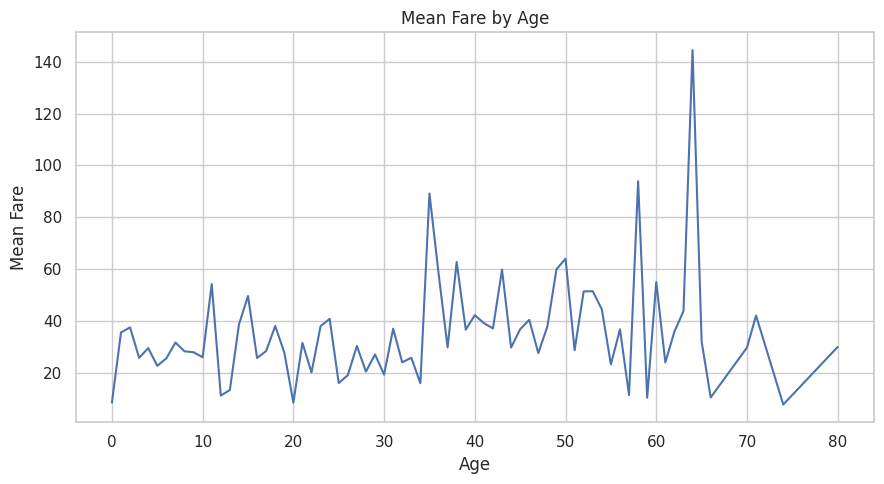

In [57]:
# Aggregate mean fare by age rounded to whole years.
age_fare = (
    titanic
    .assign(age_year=titanic["age"].round().astype(int))
    .groupby("age_year", as_index=False)["fare"]
    .mean()
)

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=age_fare,
    x="age_year",
    y="fare"
)

plt.title("Mean Fare by Age")
plt.xlabel("Age")
plt.ylabel("Mean Fare")
plt.tight_layout()
plt.show()

## 5.8 Correlation Heatmap

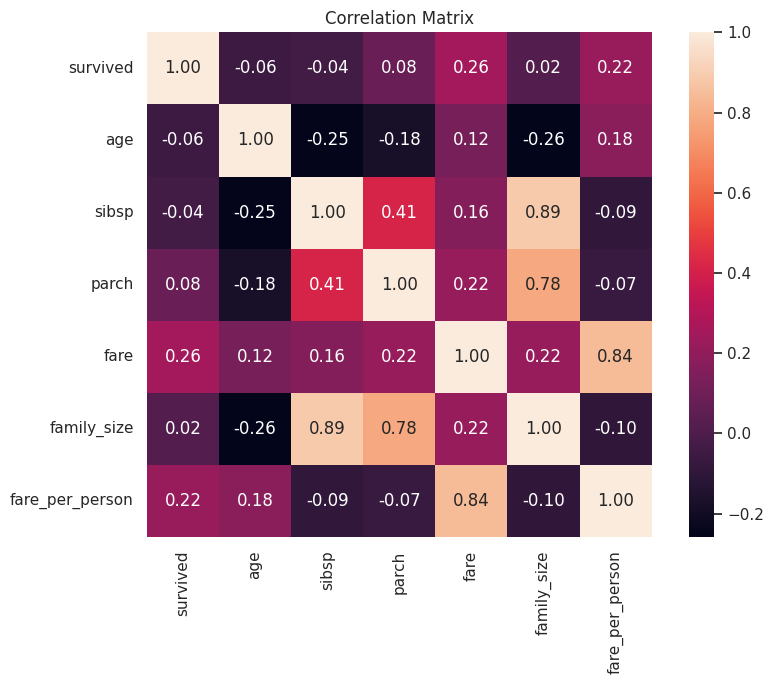

In [58]:
# Select numeric variables for correlation.
corr_vars = [
    "survived",
    "age",
    "sibsp",
    "parch",
    "fare",
    "family_size",
    "fare_per_person"
]

# Calculate Pearson correlations.
corr_matrix = titanic[corr_vars].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    square=True
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 5.9 Pair Plot

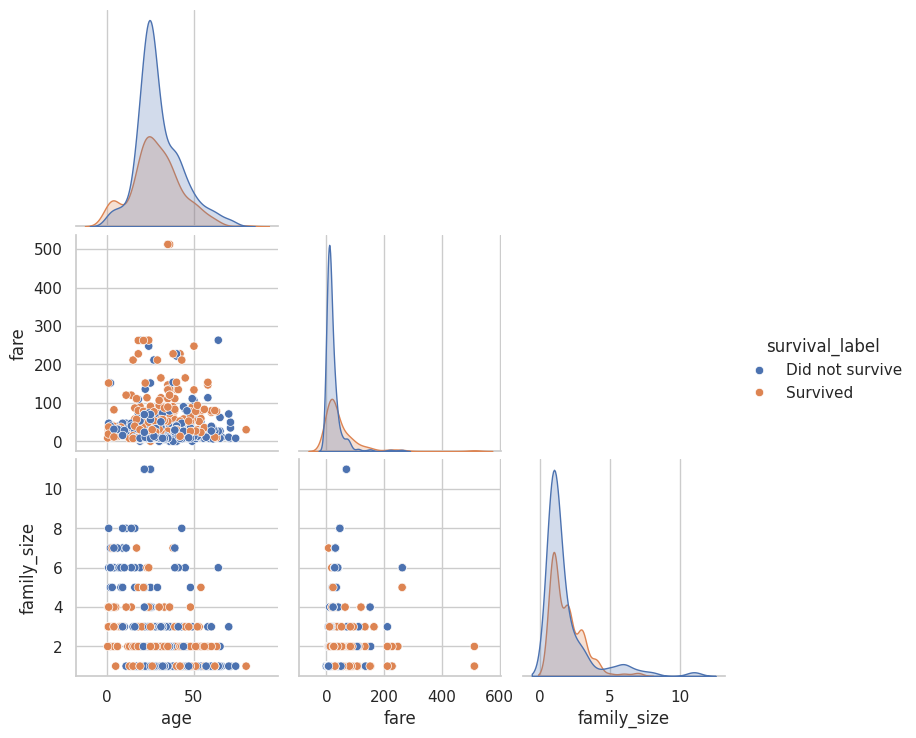

In [59]:
# Use a selected set of variables to keep the plot readable.
pair_data = titanic[
    ["age", "fare", "family_size", "survival_label"]
].copy()

sns.pairplot(
    pair_data,
    hue="survival_label",
    corner=True
)

plt.show()

## 5.10 Subplots

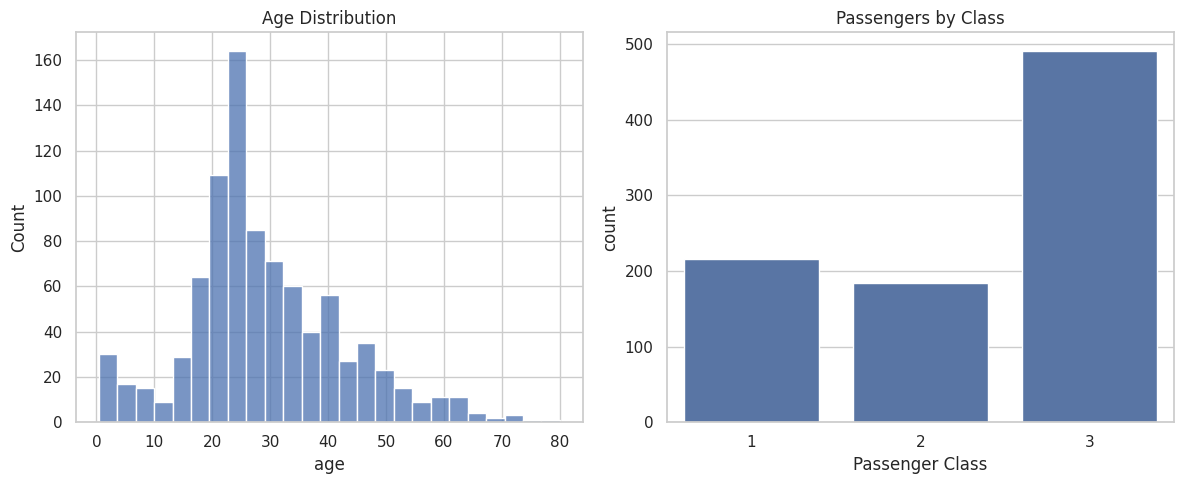

In [60]:
# Create one figure containing two axes.
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 5)
)

# Histogram on the first axis.
sns.histplot(
    data=titanic,
    x="age",
    bins=25,
    color=DEFAULT_COLOR,
    ax=axes[0]
)

axes[0].set_title("Age Distribution")

# Count plot on the second axis.
sns.countplot(
    data=titanic,
    x="pclass",
    color=DEFAULT_COLOR,
    ax=axes[1]
)

axes[1].set_title("Passengers by Class")
axes[1].set_xlabel("Passenger Class")

plt.tight_layout()
plt.show()

## 5.11 Interactive Plotly Histogram

In [61]:
# Create an interactive histogram.
fig = px.histogram(
    titanic,
    x="age",
    color="survival_label",
    nbins=30,
    title="Interactive Age Distribution by Survival"
)

# Display the interactive figure.
fig.show()

## 5.12 Interactive Plotly Scatter

In [62]:
# Create an interactive scatter plot.
fig = px.scatter(
    titanic,
    x="age",
    y="fare",
    color="survival_label",
    hover_data=["name", "class_label"],
    title="Age vs Fare — Interactive View"
)

fig.show()

## 5.13 Save a Publication-Quality Figure

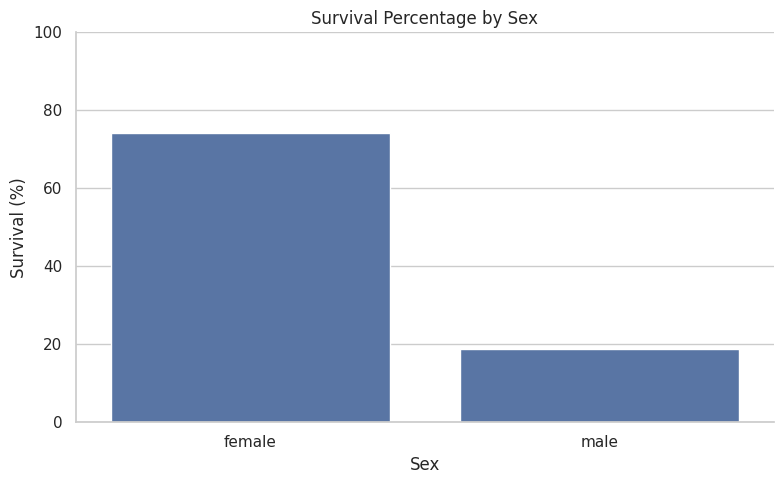

Saved: /content/survival_by_sex_300dpi.png


In [63]:
# Create a figure.
fig, ax = plt.subplots(figsize=(8, 5))

# Draw the plot.
sns.barplot(
    data=plot_data,
    x="sex",
    y="survival_percent",
    color=DEFAULT_COLOR,
    ax=ax
)

# Add readable labels.
ax.set_title("Survival Percentage by Sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Survival (%)")
ax.set_ylim(0, 100)

# Remove unnecessary top and right borders.
sns.despine()

# Improve layout.
plt.tight_layout()

# Select an output folder.
FIGURE_PATH = WORK_DIR / "survival_by_sex_300dpi.png"

# Save at high resolution.
plt.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", FIGURE_PATH)

# Module 6 — Exploratory Data Analysis (EDA)

## 6.1 Understanding the Dataset

A research-oriented EDA should connect every calculation to a question.

Examples:

- Who is represented in the dataset?
- How are age and fare distributed?
- How much missingness exists?
- What proportion survived?
- Does survival differ by sex?
- Does survival differ by passenger class?
- Are age and fare associated?
- Are there unusual/extreme observations?

## 6.2 Univariate EDA

In [64]:
# Univariate summary for age.
print(titanic["age"].describe())

# Distribution shape.
print("\nSkewness:", titanic["age"].skew())

# Age-group frequencies.
print("\nAge-group frequencies:")
print(titanic["age_group"].value_counts())

count    891.000000
mean      29.112424
std       13.304424
min        0.420000
25%       21.500000
50%       26.000000
75%       36.000000
max       80.000000
Name: age, dtype: float64

Skewness: 0.5340834483875482

Age-group frequencies:
age_group
Adult          752
Child          113
Older adult     26
Name: count, dtype: int64


## 6.3 Bivariate EDA

In [65]:
# Survival percentage by sex.
survival_sex = pd.crosstab(
    titanic["sex"],
    titanic["survived"],
    normalize="index"
).mul(100)

survival_sex

survived,0,1
sex,,
female,25.796178,74.203822
male,81.109185,18.890815


In [66]:
# Survival percentage by passenger class.
survival_class = (
    titanic
    .groupby("pclass", observed=False)["survived"]
    .mean()
    .mul(100)
)

survival_class

,survived
pclass,
1,62.962963
2,47.282609
3,24.236253


## 6.4 Multivariate EDA

In [67]:
# Survival percentage simultaneously by sex and passenger class.
multi_summary = (
    titanic
    .groupby(["sex", "pclass"], observed=False)["survived"]
    .agg(["count", "mean"])
)

# Convert survival proportion to percentage.
multi_summary["survival_percent"] = multi_summary["mean"] * 100

multi_summary.round(2)

count  mean  survival_percent
sex    pclass                               
female 1          94  0.97             96.81
       2          76  0.92             92.11
       3         144  0.50             50.00
male   1         122  0.37             36.89
       2         108  0.16             15.74
       3         347  0.14             13.54

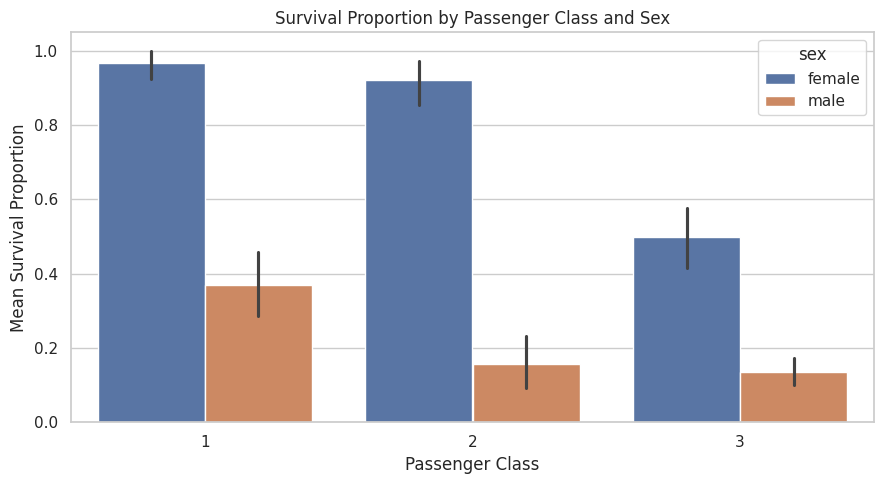

In [68]:
# Visualize survival by class with sex as a second grouping variable.
plt.figure(figsize=(9, 5))

sns.barplot(
    data=titanic,
    x="pclass",
    y="survived",
    hue="sex",
    errorbar=("ci", 95)
)

plt.title("Survival Proportion by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Mean Survival Proportion")
plt.tight_layout()
plt.show()

## 6.5 Cross-Tabulation

In [69]:
# Raw counts.
sex_survival_counts = pd.crosstab(
    titanic["sex"],
    titanic["survival_label"]
)

sex_survival_counts

survival_label,Did not survive,Survived
sex,,
female,81,233
male,468,109


In [70]:
# Row percentages.
sex_survival_percent = pd.crosstab(
    titanic["sex"],
    titanic["survival_label"],
    normalize="index"
).mul(100)

sex_survival_percent.round(1)

survival_label,Did not survive,Survived
sex,,
female,25.8,74.2
male,81.1,18.9


## 6.6 Outlier Summary

In [71]:
# Create a reusable outlier-summary function.
def outlier_summary(data, columns):
    rows = []

    for col in columns:
        lower, upper = iqr_bounds(data[col])

        flag = (
            (data[col] < lower) |
            (data[col] > upper)
        )

        rows.append({
            "variable": col,
            "lower_fence": lower,
            "upper_fence": upper,
            "outlier_n": int(flag.sum()),
            "outlier_percent": float(flag.mean() * 100)
        })

    return pd.DataFrame(rows)

outlier_summary(
    titanic,
    ["age", "fare", "family_size"]
).round(2)

,variable,lower_fence,upper_fence,outlier_n,outlier_percent
0,age,-0.25,57.75,33,3.70
1,fare,-26.72,65.63,116,13.02
2,family_size,-0.50,3.50,91,10.21


## 6.7 Automated EDA Function

In [72]:
# Build a transparent automated audit function.
def quick_eda(data):
    print("=" * 70)
    print("QUICK EDA REPORT")
    print("=" * 70)

    print("\n1. SHAPE")
    print(data.shape)

    print("\n2. DATA TYPES")
    print(data.dtypes)

    print("\n3. MISSING VALUES")
    missing = pd.DataFrame({
        "missing_n": data.isna().sum(),
        "missing_percent": (data.isna().mean() * 100).round(2)
    })
    print(missing.sort_values("missing_percent", ascending=False))

    print("\n4. DUPLICATES")
    print(data.duplicated().sum())

    print("\n5. UNIQUE VALUES")
    print(data.nunique(dropna=True).sort_values())

    print("\n6. NUMERIC SUMMARY")
    display(data.describe().T)

    print("\n7. CATEGORICAL SUMMARY")
    display(data.describe(include=["object", "category", "string"]).T)

# Run the function.
quick_eda(titanic)

QUICK EDA REPORT

1. SHAPE
(891, 21)

2. DATA TYPES
passengerid           int64
survived              int64
pclass             category
name                 object
sex                category
age                 float64
sibsp                 int64
parch                 int64
ticket               object
fare                float64
cabin                object
embarked           category
cabin_known        category
family_size           int64
is_alone             object
fare_per_person     float64
survival_label       object
title                object
class_label          object
age_group            object
fare_outlier           bool
dtype: object

3. MISSING VALUES
                 missing_n  missing_percent
passengerid              0              0.0
survived                 0              0.0
pclass                   0              0.0
name                     0              0.0
sex                      0              0.0
age                      0              0.0
sibsp              

,count,mean,std,min,25%,50%,75%,max
passengerid,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.500000,891.0000
survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.000000,1.0000
age,891.0,29.112424,13.304424,0.42,21.5000,26.0000,36.000000,80.0000
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.000000,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.000000,6.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.000000,512.3292
family_size,891.0,1.904602,1.613459,1.00,1.0000,1.0000,2.000000,11.0000
fare_per_person,891.0,19.916375,35.841257,0.00,7.2500,8.3000,23.666667,512.3292



7. CATEGORICAL SUMMARY


,count,unique,top,freq
pclass,891,3,3,491
name,891,891,"Dooley, Mr. Patrick",1
sex,891,2,male,577
ticket,891,681,347082,7
cabin,891,148,Unknown,687
embarked,891,3,S,646
cabin_known,891,2,Unknown,687
is_alone,891,2,Yes,537
survival_label,891,2,Did not survive,549
title,891,17,Mr,517


### Optional: Automated Profiling Packages

For a future advanced class, you can demonstrate packages such as `ydata-profiling`.

```python
# !pip install -q ydata-profiling
# from ydata_profiling import ProfileReport
# profile = ProfileReport(titanic, explorative=True)
# profile.to_notebook_iframe()
```

For beginners, the transparent `quick_eda()` function above is better because students can see exactly what is being calculated.

# Module 7 — Basic Inferential Statistics Preview

This section is intentionally short.

Descriptive statistics summarize the observed sample.  
Inferential statistics use sample data to make statements about a broader population under assumptions.

## 7.1 95% Confidence Interval for Mean Age

In [73]:
# Remove any remaining missing ages.
age_sample = titanic["age"].dropna()

# Sample size.
n = age_sample.size

# Sample mean.
mean_age = age_sample.mean()

# Standard error of the mean.
se_age = stats.sem(age_sample)

# Critical t value for a 95% CI.
t_critical = stats.t.ppf(
    0.975,
    df=n - 1
)

# Margin of error.
margin = t_critical * se_age

# CI endpoints.
ci_lower = mean_age - margin
ci_upper = mean_age + margin

print("Mean age:", round(mean_age, 2))
print("95% CI:", (round(ci_lower, 2), round(ci_upper, 2)))

Mean age: 29.11
95% CI: (np.float64(28.24), np.float64(29.99))


## 7.2 Welch t-test — Age by Survival

In [74]:
# Age among passengers who survived.
age_survived = titanic.loc[
    titanic["survived"] == 1,
    "age"
].dropna()

# Age among passengers who did not survive.
age_not_survived = titanic.loc[
    titanic["survived"] == 0,
    "age"
].dropna()

# Welch t-test does not assume equal group variances.
t_stat, p_value = stats.ttest_ind(
    age_survived,
    age_not_survived,
    equal_var=False
)

print("Mean age — survived:", round(age_survived.mean(), 2))
print("Mean age — did not survive:", round(age_not_survived.mean(), 2))
print("t statistic:", round(t_stat, 3))
print("p-value:", p_value)

Mean age — survived: 28.11
Mean age — did not survive: 29.74
t statistic: -1.743
p-value: 0.08174694936728187


### Interpretation reminder

A p-value is **not** the probability that the null hypothesis is true.

For a complete research interpretation, also consider:

- effect size;
- confidence interval;
- study design;
- assumptions;
- practical/scientific importance.

## 7.3 Chi-Square Test — Sex vs Survival

In [75]:
# Create a contingency table.
contingency = pd.crosstab(
    titanic["sex"],
    titanic["survived"]
)

print("Observed table:")
display(contingency)

# Run Pearson's chi-square test.
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print("Chi-square:", round(chi2, 3))
print("Degrees of freedom:", dof)
print("p-value:", p_value)

# Show expected counts.
expected_df = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)

print("\nExpected counts:")
display(expected_df.round(2))

Observed table:


survived,0,1
sex,,
female,81,233
male,468,109


Chi-square: 260.717
Degrees of freedom: 1
p-value: 1.1973570627755645e-58

Expected counts:


survived,0,1
sex,,
female,193.47,120.53
male,355.53,221.47


# Module 8 — Export Clean Data

In [76]:
# Define output file paths.
clean_csv_path = WORK_DIR / "Titanic_Cleaned_Class02.csv"
clean_excel_path = WORK_DIR / "Titanic_Cleaned_Class02.xlsx"

# Export cleaned data.
titanic.to_csv(clean_csv_path, index=False)
titanic.to_excel(clean_excel_path, index=False)

print("Saved CSV:", clean_csv_path)
print("Saved Excel:", clean_excel_path)

Saved CSV: /content/Titanic_Cleaned_Class02.csv
Saved Excel: /content/Titanic_Cleaned_Class02.xlsx


# ✅ Research-Oriented EDA Workflow

Use this checklist with future datasets.

```text
01  DEFINE the research question
02  IMPORT and audit the dataset
03  IDENTIFY the unit of observation
04  VERIFY variable names and definitions
05  STANDARDIZE labels
06  CHECK and convert data types
07  CHECK duplicates
08  CHECK impossible / implausible values
09  QUANTIFY missingness
10  DECIDE a justified missing-data strategy
11  FLAG and inspect outliers
12  CREATE derived variables carefully
13  SUMMARIZE numeric variables
14  SUMMARIZE categorical variables
15  VISUALIZE distributions
16  CROSS-TABULATE important categorical variables
17  EXPLORE key bivariate relationships
18  EXPLORE multivariable patterns
19  CHECK correlations where appropriate
20  DOCUMENT every transformation
21  SAVE a clean analysis dataset
22  EXPORT tables / figures reproducibly
```

# 📝 Practice Tasks

Try these without copying the solution first.

1. Find the passenger-class frequencies and percentages.
2. Calculate mean and median fare by passenger class.
3. Create `child = Yes/No` using age < 18.
4. Calculate survival percentage among children and adults.
5. Create a histogram of fare.
6. Create a box plot of fare by passenger class.
7. Create a bar plot of survival percentage by passenger class.
8. Create a cross-tab of embarked port and survival.
9. Flag age outliers using the IQR method.
10. Create a grouped table by sex and class.
11. Export your table to CSV.
12. Save one publication-quality figure at 300 dpi.

# 🎓 Class 02 Summary

Today you completed a large part of the practical Python data-analysis workflow:

**NumPy → pandas → cleaning → transformation → summaries → visualization → EDA → inference → export**

### Next logical classes

- deeper statistics with Python;
- probability and simulation;
- inferential statistics;
- regression;
- machine learning with scikit-learn.

**Salek Data Lab**  
*Learn → Code → Analyze → Explain → Build → Deploy*